# Paso 6: Interpretacion de los clusters

**Tercera version de este notebook.** Resumen de como llegamos hasta aca:
1. Primero (77,696 repos, k=3): nombre los clusters pensando en la idea
   original (saludable/riesgo/abandonado) -- el usuario me dijo que eso
   estaba sesgado.
2. Despues (847,133 repos, k=4 por silhouette): aparecio un cluster nuevo
   de "discusion/soporte" que note recien mirando los datos a mano.
3. Ahora: agregue esa idea como feature explicito (`ratio_issues_push`,
   Paso 4) y volvi a correr todo. El barrido de k con estos features salio
   inestable (el silhouette de un solo intento no era confiable), asi que
   probe varias semillas y **k=3 gano por ser el mas estable** -- no por
   la narrativa. Es un k=3 distinto al del punto 1: mismo numero,
   distinto motivo y (como vamos a ver) distinta composicion.

Miramos los promedios numericos, las palabras top de TF-IDF (con el
vocabulario ya limpio de basura tipo URLs, Paso 4), y ejemplos reales.
Describo primero, nombro despues.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = (SparkSession.builder
         .master("local[*]")
         .appName("interpretacion-gharchive")
         .config("spark.driver.memory", "6g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

cols_numericas = ["n_push", "n_issues", "n_pr", "n_watch", "n_fork", "n_total",
                   "n_actores", "n_horas_distintas", "n_dias_distintos",
                   "ratio_issues_push", "ratio_pr_push", "ratio_colaboracion"]

# clusters (Paso 5) y features con el tfidf (Paso 4) -- los juntamos por
# "repo" porque en Paso 5 no guardamos el tfidf, solo el cluster
clusters = spark.read.parquet("../data/processed/repos_clusterizados.parquet")
features = spark.read.parquet("../data/processed/features_repos.parquet").select("repo", "tfidf")

datos = clusters.join(features, on="repo", how="inner")
print("repos:", datos.count())
datos.groupBy("cluster").count().orderBy("cluster").show()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 23:42:12 WARN Utils: Your hostname, katana, resolves to a loopback address: 127.0.1.1; using 192.168.18.59 instead (on interface enp2s0)
26/07/11 23:42:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/11 23:42:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


repos: 847133


+-------+------+
|cluster| count|
+-------+------+
|      0|644806|
|      1| 18083|
|      2|184244|
+-------+------+



## Parte 1: promedios numericos por cluster

Vemos que tan activo/colaborativo es cada cluster en promedio.

In [2]:
promedios = datos.groupBy("cluster").avg(*cols_numericas).orderBy("cluster")
promedios.show()

# lo pasamos a pandas nada mas para graficar (son solo 3 filas)
promedios_pd = promedios.toPandas()
promedios_pd.columns = ["cluster"] + cols_numericas
promedios_pd

+-------+------------------+-------------------+------------------+-------------------+--------------------+------------------+------------------+----------------------+---------------------+----------------------+--------------------+-----------------------+
|cluster|       avg(n_push)|      avg(n_issues)|         avg(n_pr)|       avg(n_watch)|         avg(n_fork)|      avg(n_total)|    avg(n_actores)|avg(n_horas_distintas)|avg(n_dias_distintos)|avg(ratio_issues_push)|  avg(ratio_pr_push)|avg(ratio_colaboracion)|
+-------+------------------+-------------------+------------------+-------------------+--------------------+------------------+------------------+----------------------+---------------------+----------------------+--------------------+-----------------------+
|      0|3.9478618375139187|0.13633558000390816|0.2178546725681833|0.00919346283998598|0.002115364931467...| 4.313360917857464| 1.125242320946145|     1.996428383110579|   1.5972943800150743|   0.10289987336385792| 0.075

,cluster,n_push,n_issues,n_pr,n_watch,n_fork,n_total,n_actores,n_horas_distintas,n_dias_distintos,ratio_issues_push,ratio_pr_push,ratio_colaboracion
0,0,3.947862,0.136336,0.217855,0.009193,0.002115,4.313361,1.125242,1.996428,1.597294,0.102900,0.075547,0.290883
1,1,6.307250,2.092960,2.015761,5.587181,0.964774,16.967926,8.945031,7.926229,6.773931,0.984764,0.542063,0.808424
2,2,30.365971,0.298012,0.556387,0.013216,0.001786,31.235373,1.325378,8.662285,5.291168,0.065389,0.043860,0.113815


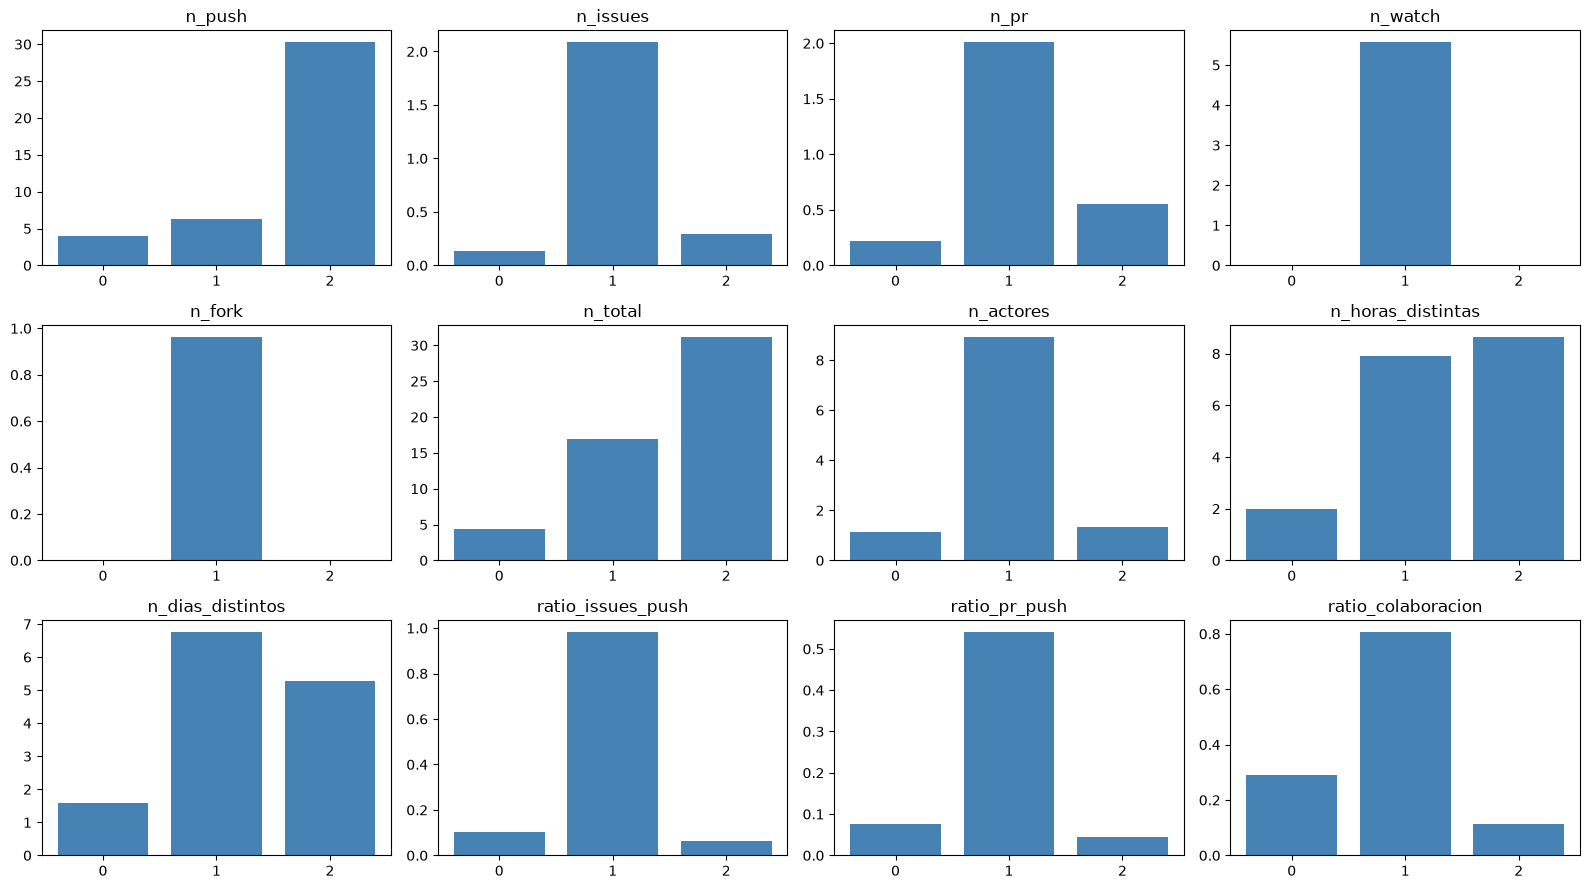

In [3]:
import matplotlib.pyplot as plt

# un mini-grafico de barras por cada feature numerico (12 ahora: 9
# conteos + 3 ratios), uno por cluster
fig, ejes = plt.subplots(3, 4, figsize=(16, 9))
ejes = ejes.flatten()

for i, columna in enumerate(cols_numericas):
    ejes[i].bar(promedios_pd["cluster"].astype(str), promedios_pd[columna], color="steelblue")
    ejes[i].set_title(columna)

plt.tight_layout()
plt.show()

## Parte 2: palabras top por cluster (TF-IDF)

Sacamos el vector TF-IDF promedio de cada cluster, y con el vocabulario
guardado en el Paso 4 (`models/pipeline_texto`) vemos que palabras pesan
mas en cada uno. Ojo: como vimos en Paso 4, la mayoria de los repos no
tiene texto, asi que estas palabras solo reflejan a la minoria que si tiene.

In [4]:
from pyspark.ml import PipelineModel
from pyspark.ml.stat import Summarizer

modelo_texto = PipelineModel.load("../models/pipeline_texto")
# el pipeline de texto ahora tiene 5 etapas (Paso 4 le agrego un filtro de
# numeros): [tokenizer, sacar_numeros, stopwords, countvectorizer, idf] --
# el vocabulario esta en la etapa 3 (countvectorizer), no la 2 como antes
vocabulario = modelo_texto.stages[3].vocabulary

# vector tfidf promedio por cluster (Summarizer hace esto de forma
# distribuida, no hay que traer todo a pandas)
resumen = Summarizer.metrics("mean")
promedio_tfidf = (datos.groupBy("cluster")
                   .agg(resumen.summary(col("tfidf")).alias("resumen"))
                   .select("cluster", "resumen.mean")
                   .collect())

TOP_N = 12
for fila in sorted(promedio_tfidf, key=lambda f: f["cluster"]):
    vector = fila["mean"].toArray()
    top_idx = vector.argsort()[::-1][:TOP_N]
    palabras_top = [vocabulario[i] for i in top_idx]
    print(f"cluster {fila['cluster']}: {palabras_top}")

cluster 0: ['update', 'add', 'fix', 'merge', 'feat', 'code', 'pull', 'request', 'readme', 'html', 'added', 'test']
cluster 1: ['fix', 'pr', 'code', 'add', 'test', 'tests', 'update', 'co', 'authored', 'commit', 'pull', 'signed']
cluster 2: ['update', 'add', 'commit', 'auto', 'license', 'fix', 'json', 'bot', 'test', 'ci', 'data', 'tests']


In [5]:
from pyspark.sql.functions import count, when, lit
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F

# cuantos repos de cada cluster SI tienen algo de texto util (norma del
# tfidf distinta de cero). Usamos funciones nativas de Spark (no un UDF de
# Python) porque un UDF aca choca con la version de numpy instalada.
norma_tfidf = F.aggregate(vector_to_array(col("tfidf")), lit(0.0), lambda acc, x: acc + x * x)
datos_con_flag = datos.withColumn("tiene_texto", norma_tfidf > 0)

datos_con_flag.groupBy("cluster").agg(
    count("*").alias("total"),
    count(when(col("tiene_texto"), True)).alias("con_texto"),
).orderBy("cluster").show()

+-------+------+---------+
|cluster| total|con_texto|
+-------+------+---------+
|      0|644806|    98547|
|      1| 18083|     6903|
|      2|184244|    30819|
+-------+------+---------+



## Parte 3: describir y nombrar los clusters

- **Cluster 0** (644,806 repos, 76.1%): push=4.0, casi todo lo demas en
  cero, 1.1 actores, ratio_colaboracion=0.29, ratio_issues_push=0.10,
  visto en 2 horas/1.6 dias en promedio. Palabras: update, add, fix,
  merge, feat, code, pull, request, readme, html -- vocabulario generico
  de programacion, nada especifico. Solo 15.3% tiene texto util. -> la
  cola larga de siempre: repos chicos, poca huella, casi sin nada que
  contar.

- **Cluster 1** (18,083 repos, 2.1%, el mas chico): esta vez junta lo que
  antes eran 2 clusters separados (comunidad + discusion). Numeros altos
  en casi todo: 8.9 actores, 5.6 watch, 2.1 issues, 2.0 PR, 0.96 fork,
  visto en 7.9 horas/6.8 dias -- Y ademas **ratio_issues_push=0.98 y
  ratio_colaboracion=0.81**, los mas altos de los 3 clusters por lejos.
  Palabras: fix, pr, code, add, test, tests, update, co, authored,
  commit, pull, signed -- "authored" y "signed" son de commits firmados
  co-autoria, tipico de colaboracion real en equipo. 38.2% tiene texto
  (el porcentaje mas alto). Ejemplos reales: `1Panel-dev/CordysCRM` (11
  actores, 13 dias distintos), `78/xiaozhi-esp32` (21 actores, 17 dias).
  -> comunidad real, con discusion activa (issues/PR) Y gente mirando
  (watch/fork), sostenida en el tiempo.

- **Cluster 2** (184,244 repos, 21.8%): push=30.4 (alto), pero
  ratio_colaboracion=0.11 (el mas bajo de los 3) y ratio_issues_push=0.065
  (casi no hay issues frente al push). 1.3 actores, visto en 8.7 horas/
  5.3 dias -- sostenido en el tiempo pero de 1 sola persona. Palabras:
  update, add, commit, **auto**, license, fix, json, **bot**, test,
  **ci** -- esta vez el vocabulario limpio dejo ver "bot" y "ci"
  clarito, que antes se tapaban con basura de URLs. Ejemplo real:
  `09jungs/fsyb` con 1121 pushes en 65 horas y 15 dias distintos, siempre
  la misma persona/proceso. -> actividad automatizada/scripted sostenida,
  sin nadie mas involucrado -- coincide con lo que ya sospechabamos antes,
  pero ahora las palabras "bot"/"ci"/"auto" lo confirman mas directo.

Nombres:

In [6]:
nombres_cluster = {
    0: "Baja actividad / cola larga",
    1: "Comunidad activa (discusion + colaboracion)",
    2: "Solitario intensivo y sostenido (automatizado)",
}

resumen_final = promedios_pd.copy()
resumen_final["nombre"] = resumen_final["cluster"].map(nombres_cluster)
resumen_final

,cluster,n_push,n_issues,n_pr,n_watch,n_fork,n_total,n_actores,n_horas_distintas,n_dias_distintos,ratio_issues_push,ratio_pr_push,ratio_colaboracion,nombre
0,0,3.947862,0.136336,0.217855,0.009193,0.002115,4.313361,1.125242,1.996428,1.597294,0.102900,0.075547,0.290883,Baja actividad / cola larga
1,1,6.307250,2.092960,2.015761,5.587181,0.964774,16.967926,8.945031,7.926229,6.773931,0.984764,0.542063,0.808424,Comunidad activa (discusion + colaboracion)
2,2,30.365971,0.298012,0.556387,0.013216,0.001786,31.235373,1.325378,8.662285,5.291168,0.065389,0.043860,0.113815,Solitario intensivo y sostenido (automatizado)


In [7]:
# unos ejemplos reales de cada cluster, para hacerlo mas concreto (y para
# yo mismo entender que es cada cluster antes de ponerle nombre)
clusters_existentes = sorted(r["cluster"] for r in datos.select("cluster").distinct().collect())
for c in clusters_existentes:
    print(f"--- cluster {c} ---")
    datos.filter(col("cluster") == c).select("repo", *cols_numericas).show(5, truncate=False)

--- cluster 0 ---


+-------------------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+-------------+------------------+
|repo                                 |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|ratio_issues_push|ratio_pr_push|ratio_colaboracion|
+-------------------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+-------------+------------------+
|0-5788719150923125/praxis            |5     |0       |0   |0      |0     |5      |1        |5                |4               |0.0              |0.0          |0.2               |
|0-erack/ScriptingReferenceData       |4     |0       |0   |0      |0     |4      |1        |4                |3               |0.0              |0.0          |0.25              |
|0001203149V/atv-estrutura-condicional|5     |0       |0   |0      |0     |5      |1        |2      

+---------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+-------------------+------------------+
|repo                 |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|ratio_issues_push|ratio_pr_push      |ratio_colaboracion|
+---------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+-------------------+------------------+
|0rtbo/convexpo       |0     |0       |0   |2      |1     |3      |3        |1                |1               |0.0              |0.0                |1.0               |
|1Panel-dev/CordysCRM |8     |0       |2   |7      |1     |18     |11       |13               |13              |0.0              |0.2222222222222222 |0.6111111111111112|
|1weiho/open-slide    |6     |0       |1   |8      |1     |16     |10       |9                |5               |0.0              |0.14285714285714285|

+------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+------------------+--------------------+
|repo                    |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|ratio_issues_push|ratio_pr_push     |ratio_colaboracion  |
+------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+-----------------+------------------+--------------------+
|00quasr/commit          |8     |0       |0   |0      |0     |8      |1        |5                |3               |0.0              |0.0               |0.125               |
|05Huang/FullScopeTest   |7     |0       |0   |0      |0     |7      |1        |4                |3               |0.0              |0.0               |0.14285714285714285 |
|06Etka/AGJ2025          |14    |0       |10  |0      |0     |24     |3        |1                |1               |0.0            

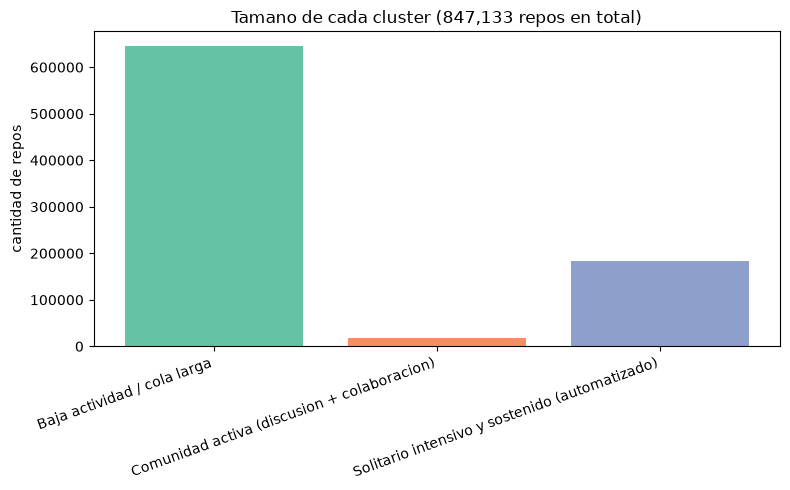

In [8]:
# grafico final: tamano de cada cluster, con su nombre
tamanos_pd = datos.groupBy("cluster").count().orderBy("cluster").toPandas()
tamanos_pd["nombre"] = tamanos_pd["cluster"].map(nombres_cluster)

# antes tenia una lista de 3 colores fija a mano -- con k=4 eso rompio
# (matplotlib necesita un color por barra). Mejor uso un colormap que se
# ajuste solo a cuantos clusters haya, asi no se rompe si el k cambia de nuevo.
colores = plt.cm.Set2(range(len(tamanos_pd)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tamanos_pd["nombre"], tamanos_pd["count"], color=colores)
ax.set_ylabel("cantidad de repos")
ax.set_title(f"Tamano de cada cluster ({tamanos_pd['count'].sum():,} repos en total)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Conclusiones

De 3,419,971 repos vistos en ~124 horas de GH Archive (12 dispersas +
57 dispersas nuevas + un bloque de 4 dias seguidos, ago 2025 - jul 2026),
quedandonos con los 847,133 que tuvieron al menos 3 eventos, y con 12
features numericos (9 conteos + 3 razones) + TF-IDF de texto (vocabulario
limpio de basura de URLs), KMeans con **k=3** (elegido por estabilidad
ante distintas semillas, no por silhouette de un solo intento ni por la
narrativa original) encontro:

1. **Baja actividad / cola larga** (644,806 repos, 76.1%): la inmensa
   mayoria de GitHub -- repos chicos, 1 solo actor, casi sin huella.
2. **Comunidad activa** (18,083 repos, 2.1%): el mas chico, pero el que
   junta colaboracion real (ratio_colaboracion=0.81) Y discusion activa
   (ratio_issues_push=0.98) -- esto es lo mas parecido a un proyecto open
   source "sano" en el sentido tradicional.
3. **Solitario intensivo y sostenido** (184,244 repos, 21.8%): mucho
   push (30/repo), sostenido en el tiempo (8.7 horas/5.3 dias), pero de
   una sola persona (ratio_colaboracion=0.11) -- las palabras "bot",
   "auto" y "ci" (ahora visibles gracias al vocabulario limpio) apuntan
   a automatizacion.

**Sobre el sesgo (por que esto ya no es "solo" saludable/riesgo/
abandonado):** los 3 clusters SI terminan pareciendose a la idea
original del proyecto, pero llegamos por un camino distinto cada vez:
primero salio de asumir la narrativa (sesgado), despues aparecio un 4to
cluster que la narrativa no preveia (con menos features), y ahora, con
mejores features, ese 4to cluster se fusiono de nuevo con el de
"comunidad" porque resulta que la colaboracion real Y la discusion activa
van juntas en los datos -- no son cosas separadas. Es una conclusion mas
solida que la primera porque sobrevivio a 3 vueltas de revision distinta,
no porque la hayamos buscado.

**Que se agrego en esta ultima vuelta:**
- 3 features de razon (`ratio_issues_push`, `ratio_pr_push`,
  `ratio_colaboracion`) que explicitaron un patron que antes solo se veia
  mirando los datos a mano.
- Limpieza de texto mejorada: se saco numeros sueltos y basura de URLs
  del vocabulario TF-IDF -- las palabras top ahora dicen algo real
  ("authored", "signed", "bot", "ci") en vez de fragmentos de link.
- Prueba de estabilidad con varias semillas antes de elegir k -- un
  silhouette de una sola corrida puede ser enganoso si KMeans no converge
  siempre al mismo lugar.
- Visualizacion PCA 2D de los clusters (ver Paso 5), para la sustentacion.

**Limitaciones que siguen (para la sustentacion):**
- El texto (TF-IDF) sigue disponible solo para una minoria (15-38% segun
  el cluster).
- Los nombres de los clusters siguen siendo nuestra interpretacion, no
  una etiqueta que vino en los datos.
- Seguimos sin saber la causa real del patron "mas push, menos todo lo
  demas" que se confirmo en el Paso 3 (mas actividad automatizada? un
  cambio en la plataforma? no lo podemos responder solo con estos datos).